# Total volume analysis

Preliminary analysis on total tissue volume. Just for looking over.

To deal with missing data, use the `avg_vol` function for regression.

To deal with individual differences, work with intracranial total volume

In [10]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import SUITPy as suit
import tissue_extractor as te

import nibabel as nib
from nilearn import plotting as npl

from pathlib import Path
import os

In [11]:
# directories
base_dir = '/cifs/diedrichsen/data/smarts_cerebellum'
anat_dir = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals'
p_df = pd.read_csv('/cifs/diedrichsen/data/smarts_cerebellum/participants_anat.tsv', sep = '\t')

## Step 1

Look at total wmv in cerebellum for only those subjects that have (a) >1 measurement weeks, (b) W0

Look at weekly WMV relative to W0

There are two ways to get tWMV:

- Use sum of WMV from SUIT-based ROIs (bandage solution)

- calculate total volume of white matter from sum of voxels

In both of these, use tissue extractor module (summarize function...under construction) to get the df

In [12]:
df = pd.read_csv(f'{base_dir}/wmv_total_atlas_summarized.tsv', sep = '\t')

In [13]:
df['hemisphere'] = df['regionname'].str[0]

# subjects with W0
diff_df = pd.DataFrame()

for subj in df['subj_id'].unique():
    refT1 = (df.loc[(df['subj_id']==subj), 'RefT1'].iloc[0]).strip()
    if not refT1=='W0':
        print(subj, "skipped")
        continue
    diff_df = pd.concat([diff_df, df[df['subj_id']==subj]])

CU_2697 skipped
JHU_2282 skipped
JHU_2577 skipped
JHU_2684 skipped
JHU_3176 skipped
UZ_2365 skipped
UZ_2450 skipped
UZ_2595 skipped
UZ_3030 skipped
UZ_3224 skipped
UZ_3228 skipped


In [14]:
# total wmv per week

week_vols = diff_df.groupby(['subj_id', 'week', 'isPatient', 
                             'hemisphere', 'LesionSide', 'LesionLocation', 'RefT1']
                             ).agg({'ind_vol': 'sum'}
                             ).reset_index()

In [15]:
# change in total WM volume relative to the first week per hemisphere (left, right, vermis)

#for subj in week_vols.loc[week_vols['isPatient']==1, 'subj_id'].unique():
for subj in week_vols['subj_id'].unique():
    for week in week_vols.loc[week_vols['subj_id']==subj, 'week'].unique():
        for hem in week_vols.loc[week_vols['subj_id']==subj, 'hemisphere'].unique():
            curr_vol = week_vols.loc[(week_vols['subj_id'] == subj) & (week_vols['week'] == week) & (week_vols['hemisphere'] == hem), 'ind_vol'].iloc[0]
            ref_vol = week_vols.loc[(week_vols['subj_id'] == subj) & (week_vols['week'] == refT1) & (week_vols['hemisphere'] == hem), 'ind_vol'].iloc[0]
            week_vols.loc[(week_vols['subj_id'] == subj) & (week_vols['week'] == week) & (week_vols['hemisphere'] == hem), 'vol_diff'] = curr_vol - ref_vol

In [17]:
week_vols

,subj_id,week,isPatient,hemisphere,LesionSide,LesionLocation,RefT1,ind_vol,vol_diff
0,CUP_1001,W0,0,L,none,none,W0,9053.748888,0.000000
1,CUP_1001,W0,0,R,none,none,W0,8894.183198,0.000000
2,CUP_1001,W0,0,V,none,none,W0,500.239134,0.000000
3,CUP_1001,W4,0,L,none,none,W0,6820.745517,-2233.003372
4,CUP_1001,W4,0,R,none,none,W0,6378.704657,-2515.478541
...,...,...,...,...,...,...,...,...,...
517,UZ_3248,W4,1,R,left,subcortical,W0,5942.864988,75.512090
518,UZ_3248,W4,1,V,left,subcortical,W0,411.528177,36.675230
519,UZ_3248,W52,1,L,left,subcortical,W0,6451.555167,278.655807
520,UZ_3248,W52,1,R,left,subcortical,W0,5555.327662,-312.025237


In [ ]:
# create dummy column: ipsilesional = 0, contralesional = 1, none = 2 (no stroke), vermis = 3

hem_dict = {
    'L': 'left',
    'R': 'right',
    'V': 'vermis'
}

mapping = week_vols['hemisphere'].map(hem_dict) # map hemisphere names to match LesionSide names

week_vols['side_type'] = 2 # default none

# for patient rows: set ipsi-, contra-lesional, vermis
mask_patient = week_vols['isPatient']==1
mask_hemi_lr = mapping.isin(['left', 'right'])
week_vols.loc[mask_patient & (mapping == week_vols['LesionSide']), 'side_type'] = 0 # ipsilesional
week_vols.loc[mask_patient & mask_hemi_lr & (mapping !=week_vols['LesionSide']), 'side_type'] = 1 # contralesional
week_vols.loc[mask_patient & (week_vols['hemisphere']=='V'), 'side_type'] = 3 # vermis

In [ ]:
# put descriptive titles on plots
titles = {
    '0': 'ipsilesional',
    '1': 'contralesional',
    '2': 'control',
    '3': 'vermis'
}

# fix: should have one value per subject, so no error bars. Check: week ordering (should be using 0, 4, ..., not W0, W4, ...), and the dummy column to assign ipsai, contra, vermis

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


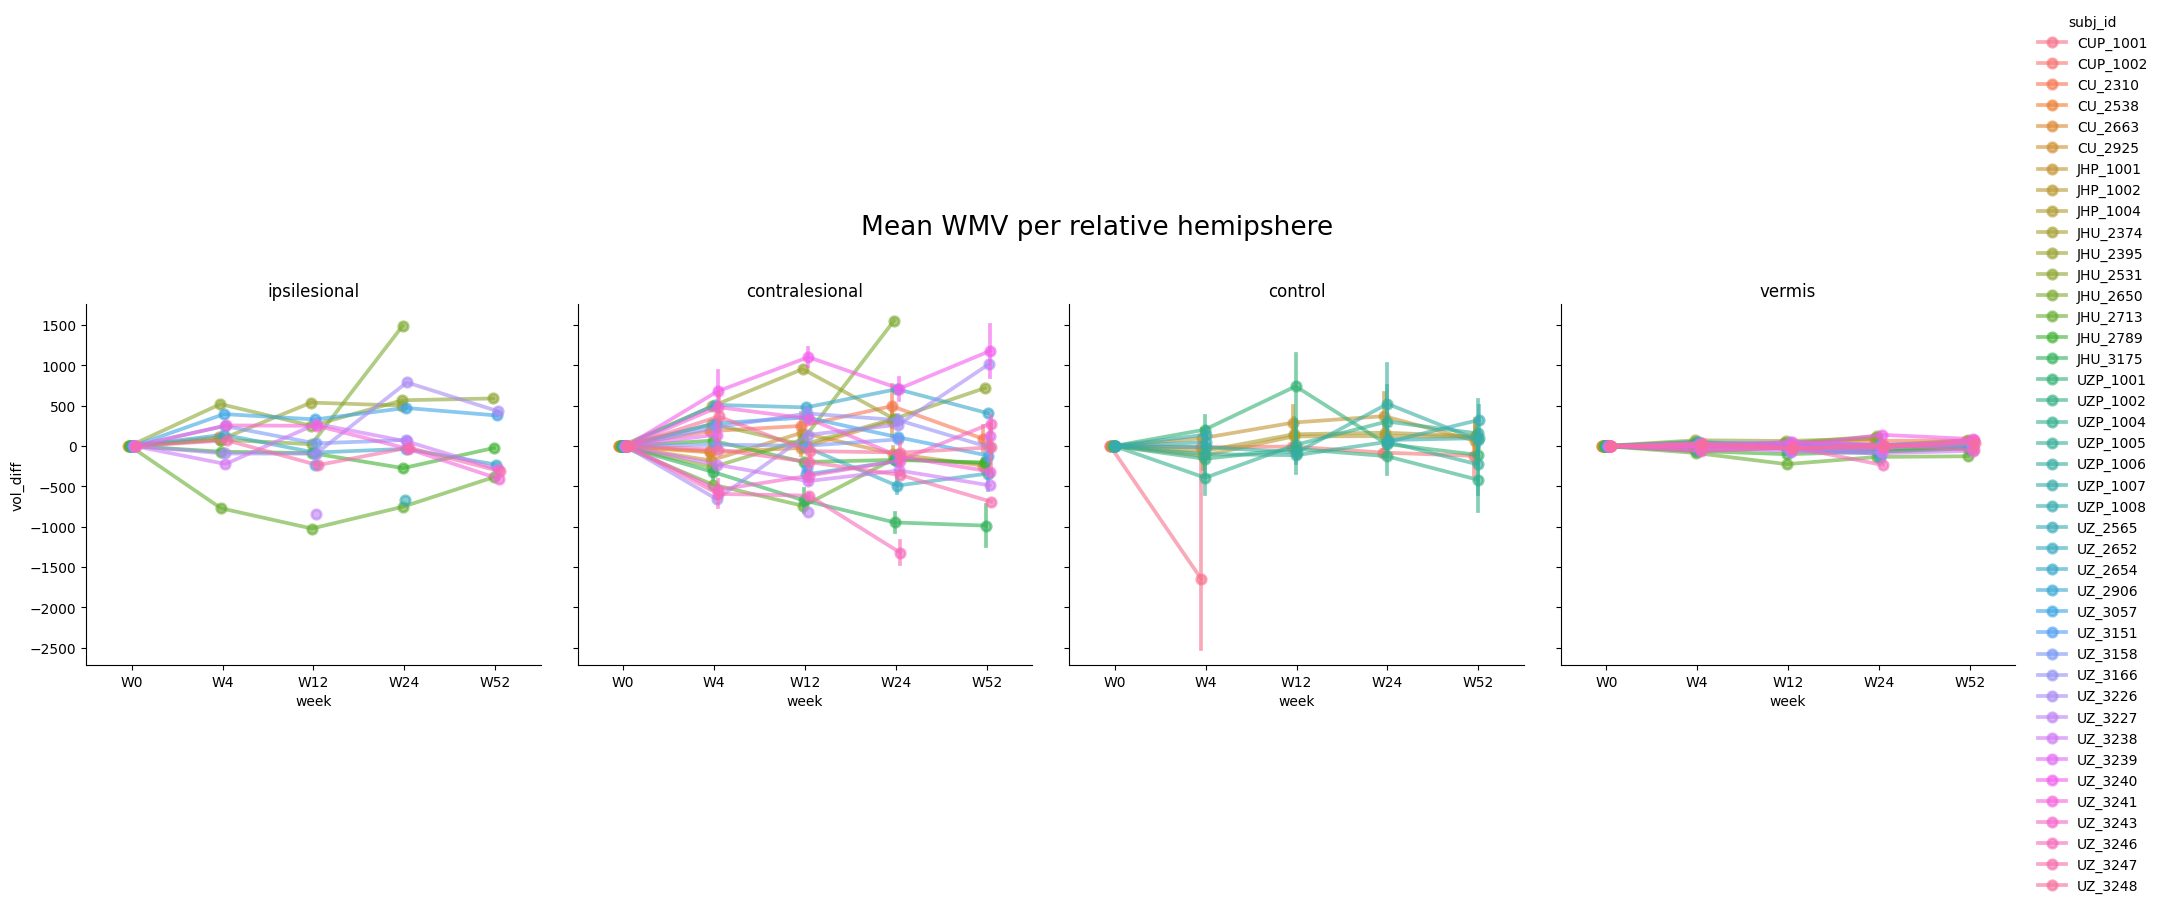

In [36]:
diff_plots_wmv_mean = sns.catplot(data = week_vols,
            x='week', y='vol_diff',
            hue = 'subj_id', col = 'side_type',
            kind = 'point',
            alpha = 0.6, dodge = 0.1
            )

for ax in diff_plots_wmv_mean.axes.flat:
    previous_title = ax.get_title()
    value = (previous_title.split('=')[1]).strip() # get dummy value
    ax.set_title(titles[value])

diff_plots_wmv_mean.figure.suptitle('Mean WMV per relative hemipshere', fontsize = 19)
diff_plots_wmv_mean.figure.subplots_adjust(top = 0.8)
plt.show()
# vermis is coded as '3', gets its own plot

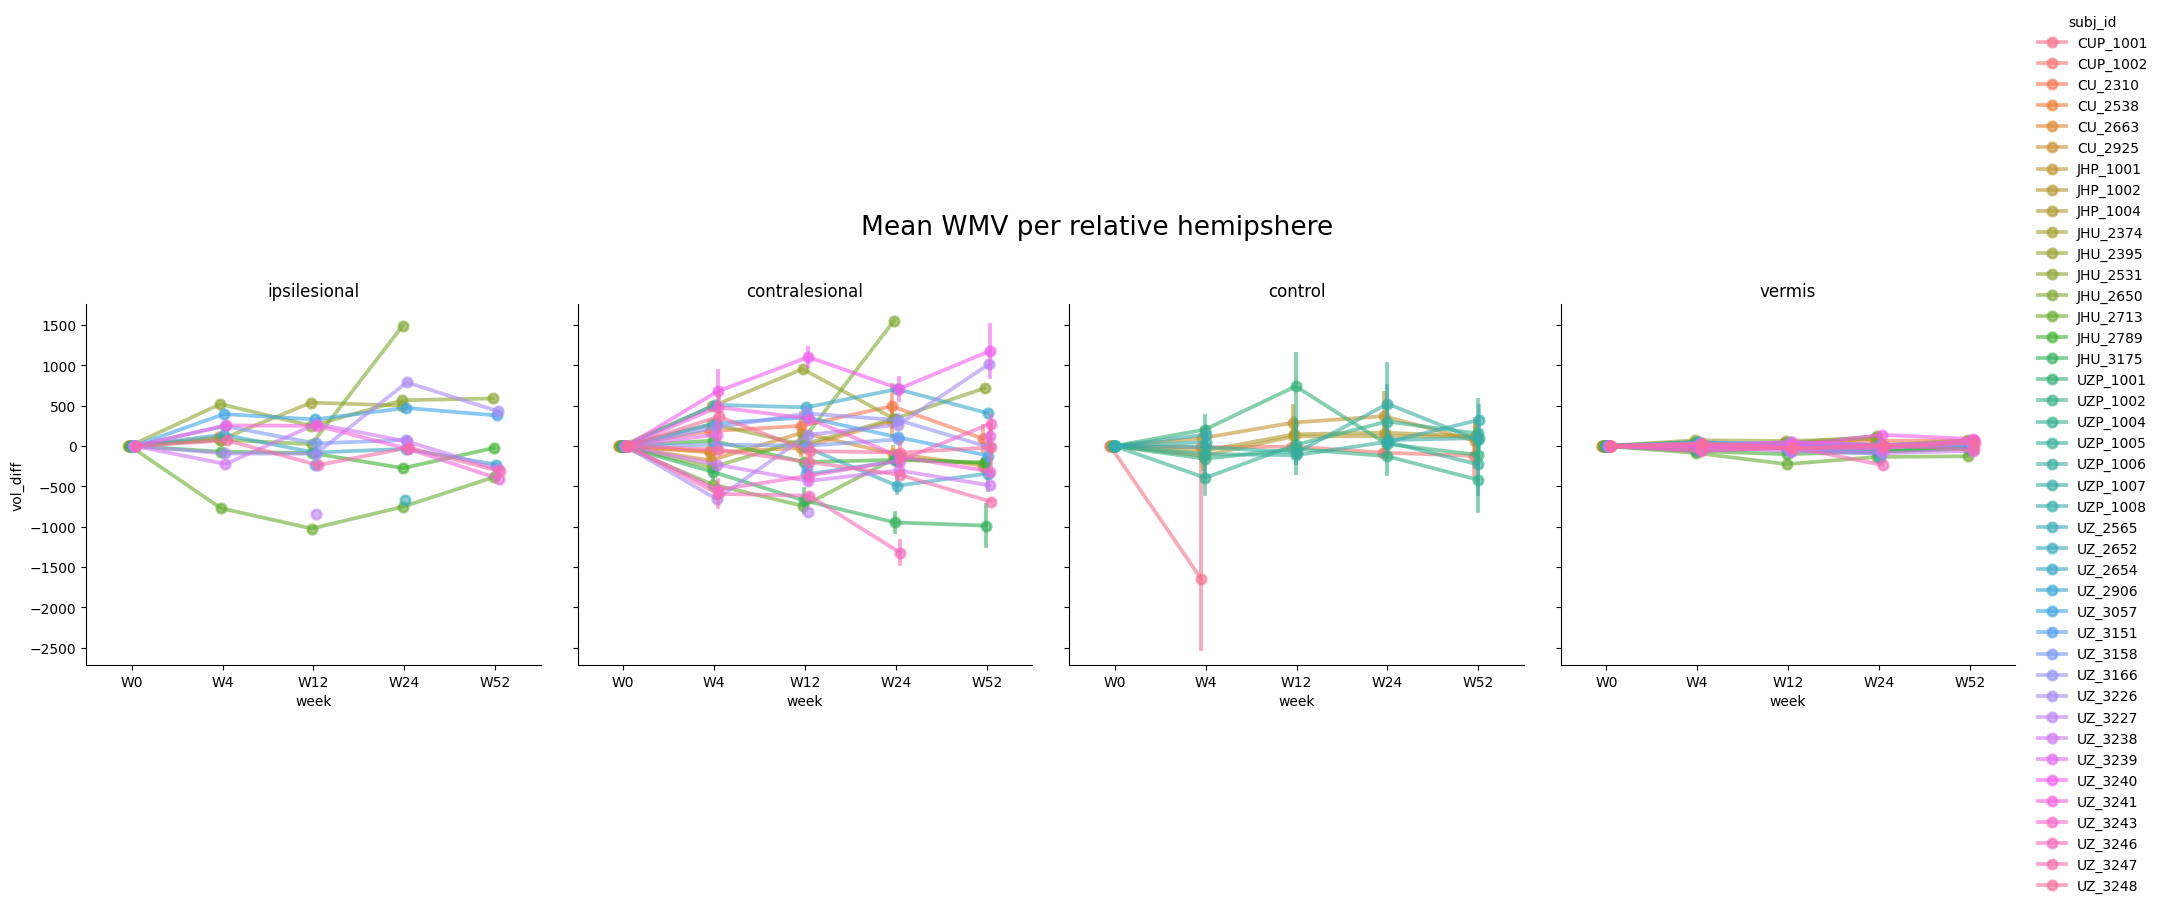
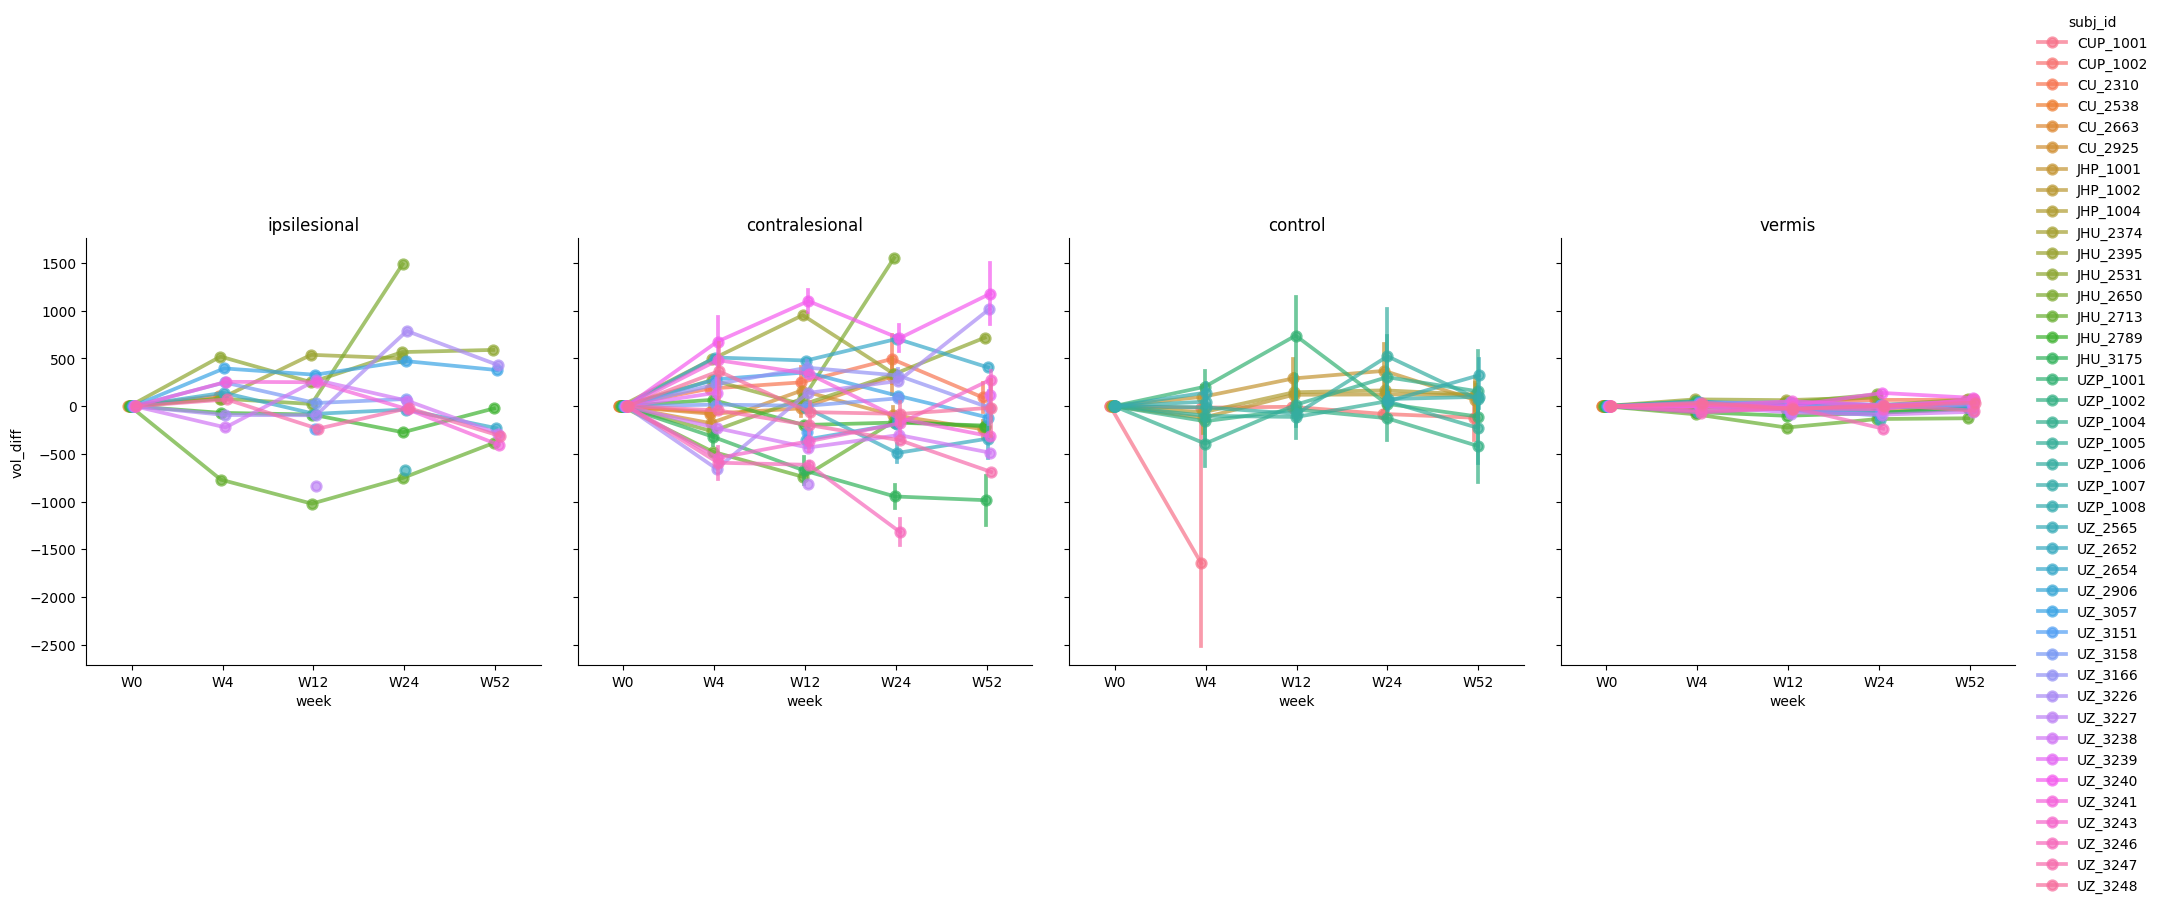
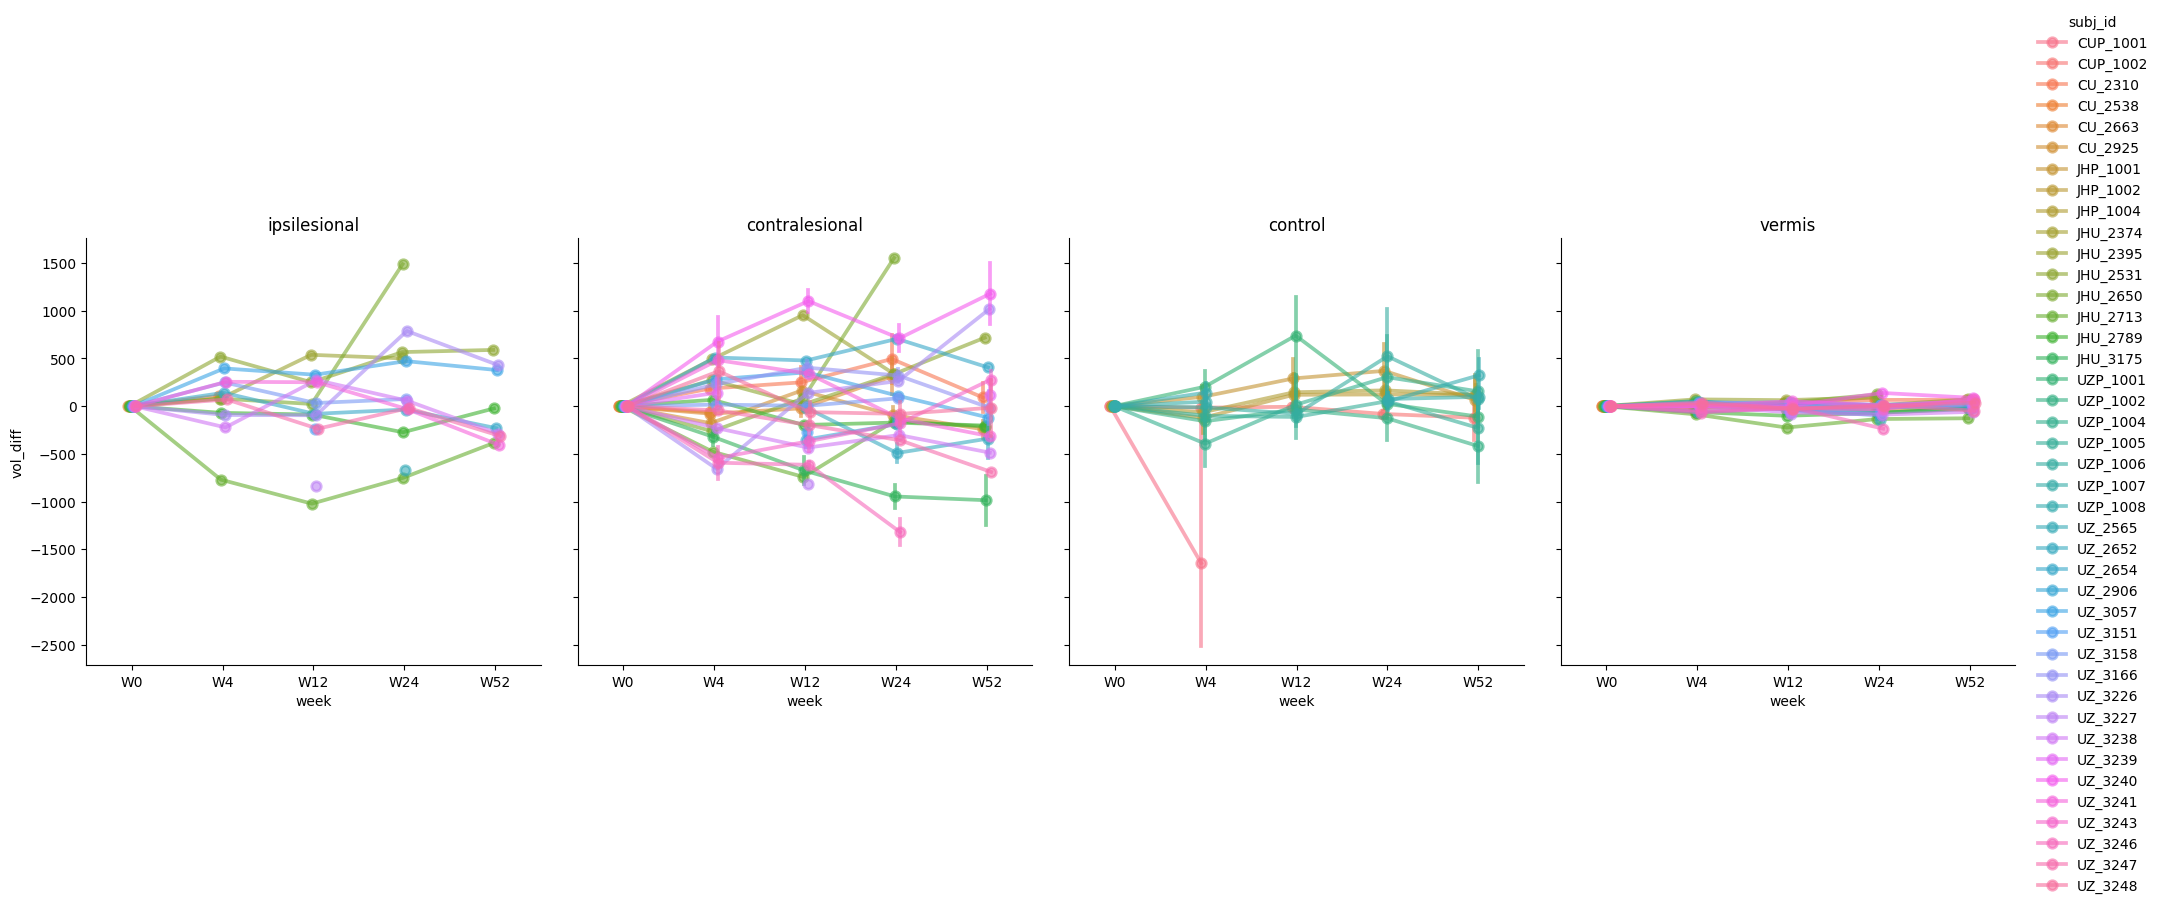
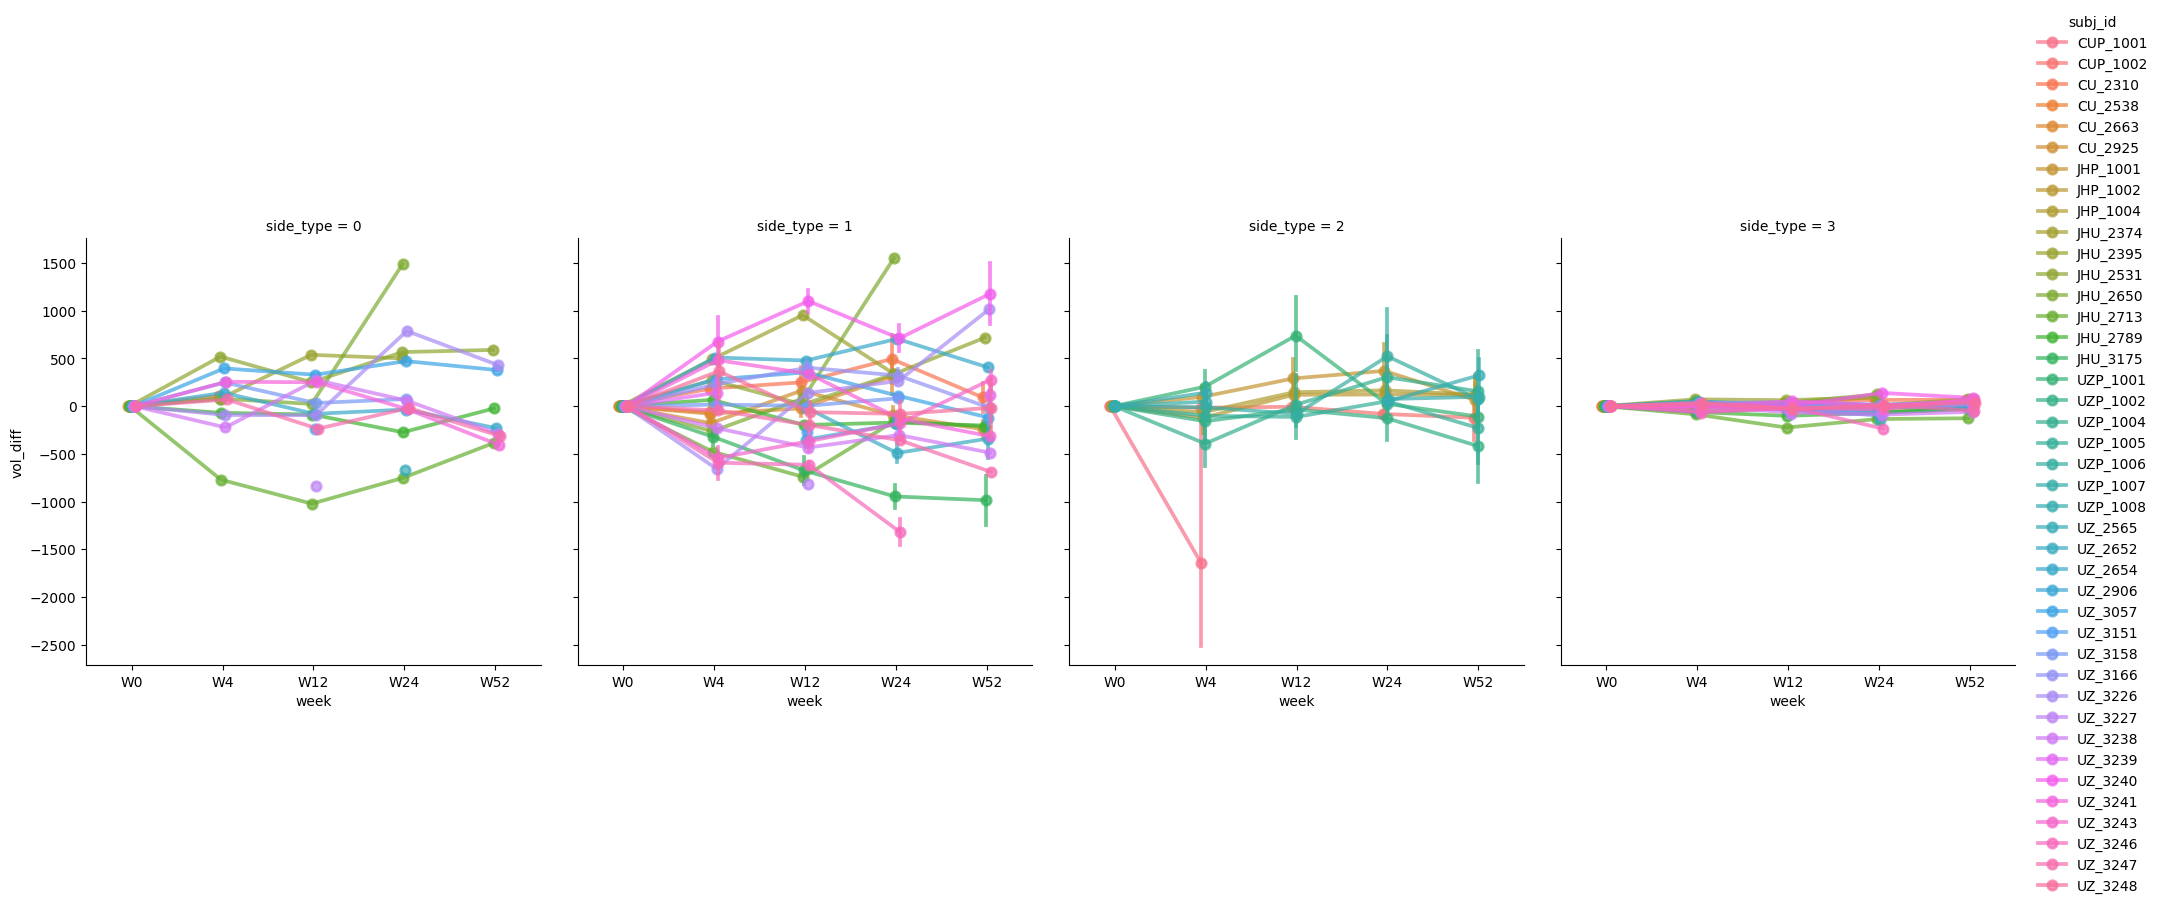

In [25]:
week_vols

,subj_id,week,isPatient,hemisphere,LesionSide,LesionLocation,RefT1,ind_vol,vol_diff,side_type
0,CUP_1001,W0,0,L,none,none,W0,9053.748888,0.000000,2
1,CUP_1001,W0,0,R,none,none,W0,8894.183198,0.000000,2
2,CUP_1001,W0,0,V,none,none,W0,500.239134,0.000000,2
3,CUP_1001,W4,0,L,none,none,W0,6820.745517,-2233.003372,2
4,CUP_1001,W4,0,R,none,none,W0,6378.704657,-2515.478541,2
...,...,...,...,...,...,...,...,...,...,...
517,UZ_3248,W4,1,R,left,subcortical,W0,5942.864988,75.512090,1
518,UZ_3248,W4,1,V,left,subcortical,W0,411.528177,36.675230,3
519,UZ_3248,W52,1,L,left,subcortical,W0,6451.555167,278.655807,1
520,UZ_3248,W52,1,R,left,subcortical,W0,5555.327662,-312.025237,1


/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


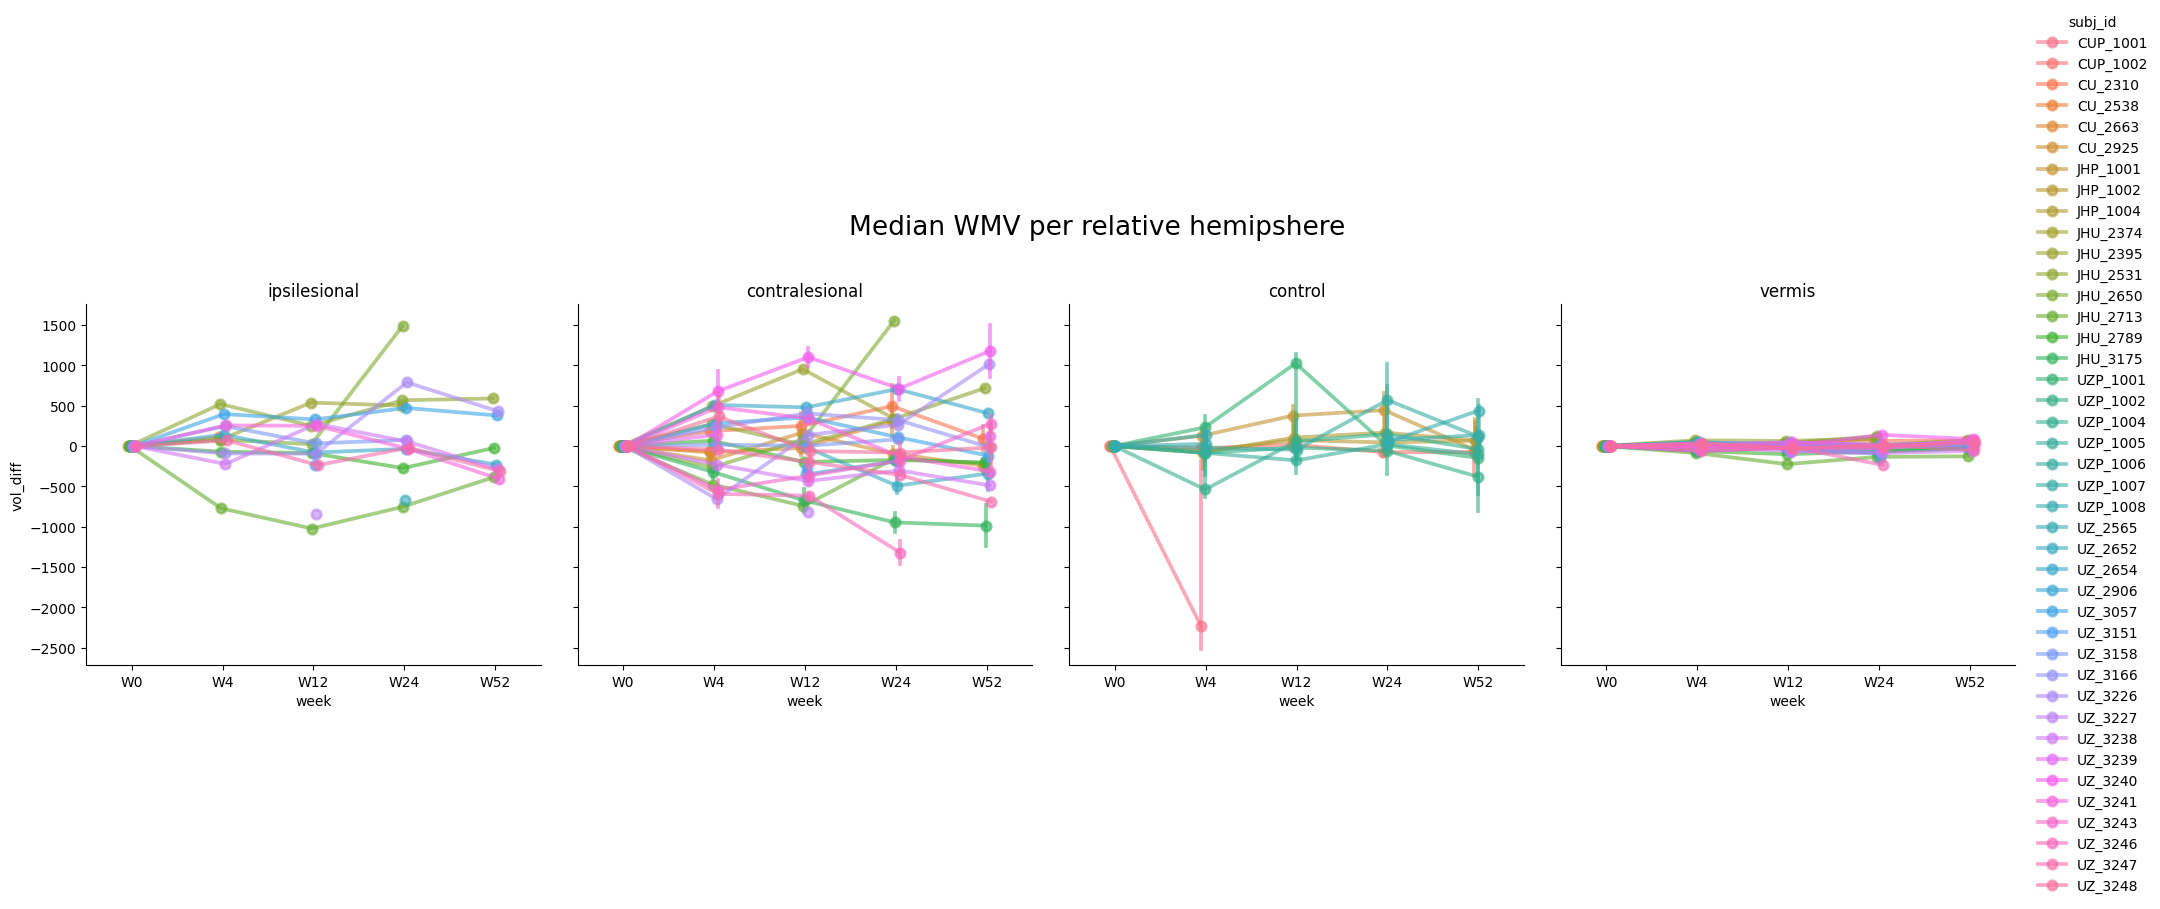

In [35]:
# plot the medians
diff_plots_wmv_median = sns.catplot(data = week_vols,
            x='week', y='vol_diff',
            hue = 'subj_id', col = 'side_type',
            kind = 'point',
            estimator = 'median',
            alpha = 0.6, dodge = 0.1
            )

for ax in diff_plots_wmv_median.axes.flat:
    previous_title = ax.get_title()
    value = (previous_title.split('=')[1]).strip() # get dummy value
    ax.set_title(titles[value])

diff_plots_wmv_median.figure.suptitle('Median WMV per relative hemipshere', fontsize = 19)
diff_plots_wmv_median.figure.subplots_adjust(top = 0.8)
plt.show()

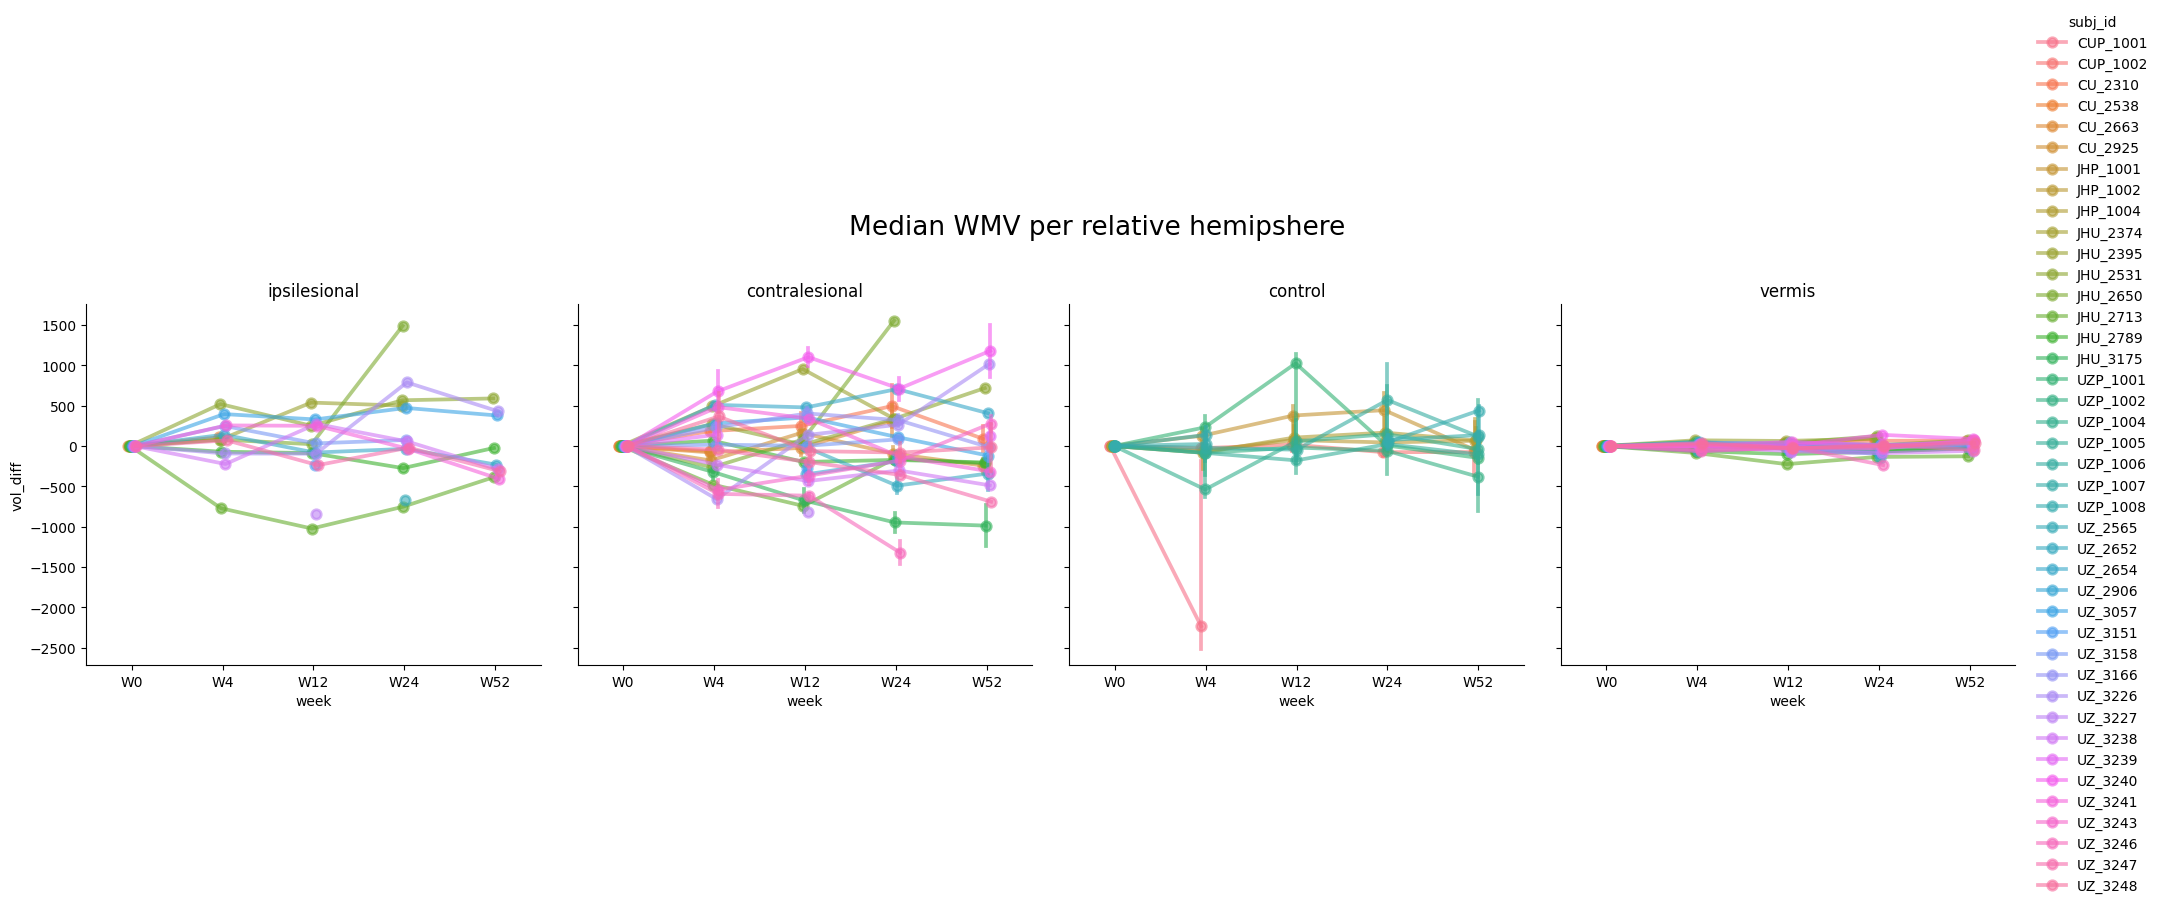